## Predicción de abandono de clientes en Telco

Alejandro José Orellana Reyes  
**Dataset:** `telco_churn.csv`\

## Estructura

1. Contexto de negocio
2. Problema de Machine Learning
3. Variables del modelo
4. Validación exploratoria (EDA)
5. Validación técnica
6. Conclusiones y limitaciones

> La justificación de negocio, los riesgos y los supuestos detallados se recogen en la **Ficha técnica del modelo** (documento aparte); este cuaderno no los repite.

### Configuración

Cargo las librerías de análisis y fijo un estilo de gráficos consistente.

Requisitos: `pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy` y `statsmodels`  
 Si falta `statsmodels`: `%pip install -q statsmodels`.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 40)

In [3]:
# Dataset del repositorio
df = pd.read_csv("telco_churn.csv")
print("Filas y columnas:", df.shape)
df.head()

Filas y columnas: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# estructura de los datos
df.dtypes.value_counts()

str        18
int64       2
float64     1
Name: count, dtype: int64

## 1. Contexto de negocio

Telco (CompaCompany) pierde cerca del **26.5 %** de sus clientes cada mes, por lo que la dirección necesita dirigir las acciones de retención (con presupuesto limitado) a los clientes con mayor riesgo.

> El problema de negocio, los KPI y la justificación de usar analítica predictiva se desarrollan en la **Ficha técnica del modelo** (documento aparte).

## - Problema de Machine Learning

| Elemento | Definición |
|---|---|
| **Variable objetivo** | `Churn` → `Yes = 1` (abandona) / `No = 0` (permanece) |
| **Tipo de problema** | Clasificación binaria |
| **Unidad de predicción** | un cliente activo |
| **Horizonte** | próximos 30 días |

Con un desbalance de 73.5 % / 26.5 %, la evaluación se centrará en el **recall** de la clase churn y no en la *accuracy*.

> La traducción del KPI, la justificación de la ventana de 30 días y sus limitaciones están en la **Ficha técnica del modelo**.

## - Variables del modelo

**Predictoras seleccionadas:** `tenure`, `Contract`, `InternetService`, `MonthlyCharges`, `PaymentMethod`, `PaperlessBilling`, `TechSupport`, `OnlineSecurity`, `SeniorCitizen`, `Partner`, `Dependents`, `MultipleLines`.

**Descartadas:** `customerID` y `gender` (sin poder predictivo), `PhoneService` (casi constante) y `TotalCharges` (**fuga de datos** y colinealidad con `tenure` y `MonthlyCharges`).

> La justificación de negocio de cada variable y las correlaciones esperadas se detallan en la **Ficha técnica del modelo** (apartados 3 y 4).

## - Validación exploratoria (EDA)

### Análisis de valores faltantes

In [4]:
# TotalCharges llega como texto a causa de 11 celdas en blanco: se limpia a numérico.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

faltantes = df.isna().sum()
print("Variables con valores faltantes:")
print(faltantes[faltantes > 0])

# Esos 11 clientes tienen tenure = 0 (recién ingresados, aun sin facturación emitida).
print("\nTenure de los clientes sin TotalCharges:", df.loc[df["TotalCharges"].isna(), "tenure"].unique())
print("Porcentaje del total: {:.2f} %".format(100 * df["TotalCharges"].isna().mean()))

Variables con valores faltantes:
TotalCharges    11
dtype: int64

Tenure de los clientes sin TotalCharges: [0]
Porcentaje del total: 0.16 %


Solo `TotalCharges` tiene faltantes (11 casos, 0.16 %), y todos corresponden a clientes con antigüedad cero, algunos son cuentas nuevas a las que todavía no se les ha emitido la primera factura. Como `TotalCharges` se descarta del modelo, estos nulos no afectan al conjunto de variables y los descriptivos se tratan separado (o se omiten del cálculo).

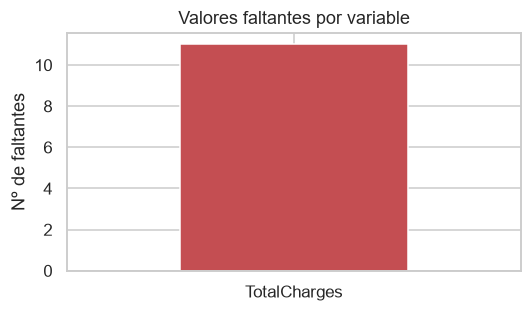

In [5]:
# Evidencia visual de los faltantes.
falt = df.isna().sum()
falt = falt[falt > 0]
ax = falt.plot(kind="bar", color="#c44e52", figsize=(5, 3))
ax.set_title("Valores faltantes por variable")
ax.set_ylabel("Nº de faltantes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Distribuciones de datos

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


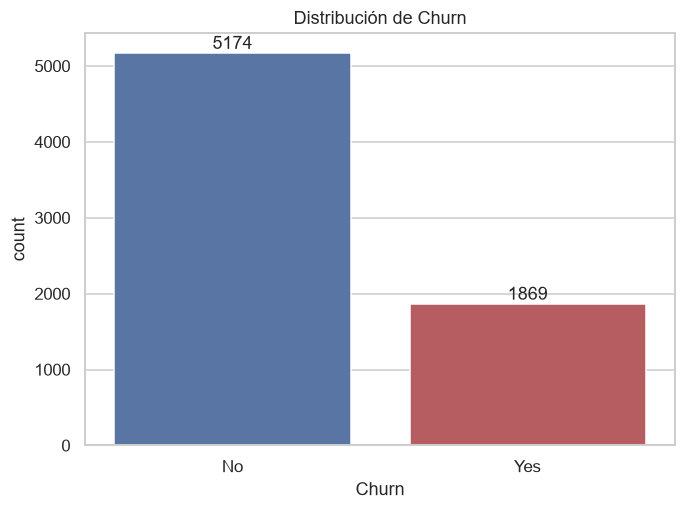

In [6]:
# Distribución del target: hay desbalance moderado (73.5 % / 26.5 %).
print(df["Churn"].value_counts())
print((df["Churn"].value_counts(normalize=True) * 100).round(1))

ax = sns.countplot(x="Churn", data=df, hue="Churn", palette=["#4c72b0", "#c44e52"], legend=False)
ax.set_title("Distribución de Churn")
for c in ax.containers:
    ax.bar_label(c)
plt.tight_layout()
plt.show()

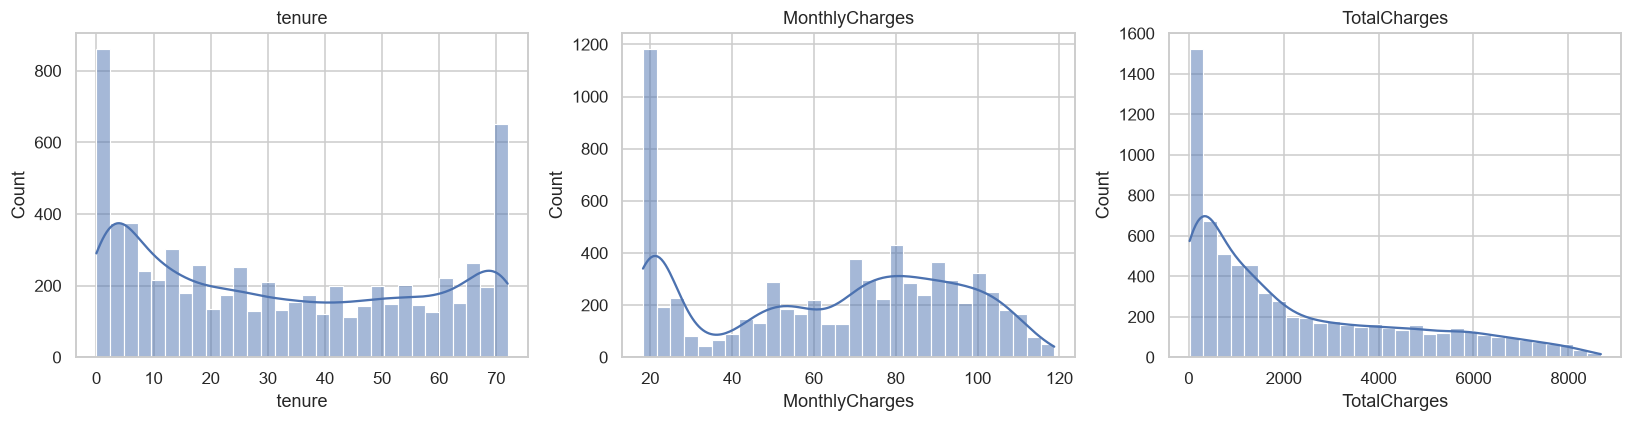

In [7]:
# Histogramas de las variables numéricas candidatas.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.histplot(df[col], bins=30, kde=True, ax=ax, color="#4c72b0")
    ax.set_title(col)
plt.tight_layout()
plt.show()

La clase positiva (churn) representa el 26.5 %, un desbalance que exige métricas distintas de la *accuracy*. `tenure` es **bimodal**: hay muchos clientes muy nuevos y muchos muy antiguos, con un valle intermedio. `MonthlyCharges` se reparte en casi todo el rango con un pico en la zona baja. `TotalCharges` tiene una cola hacia valores altos, coherente con los clientes de larga antigüedad.

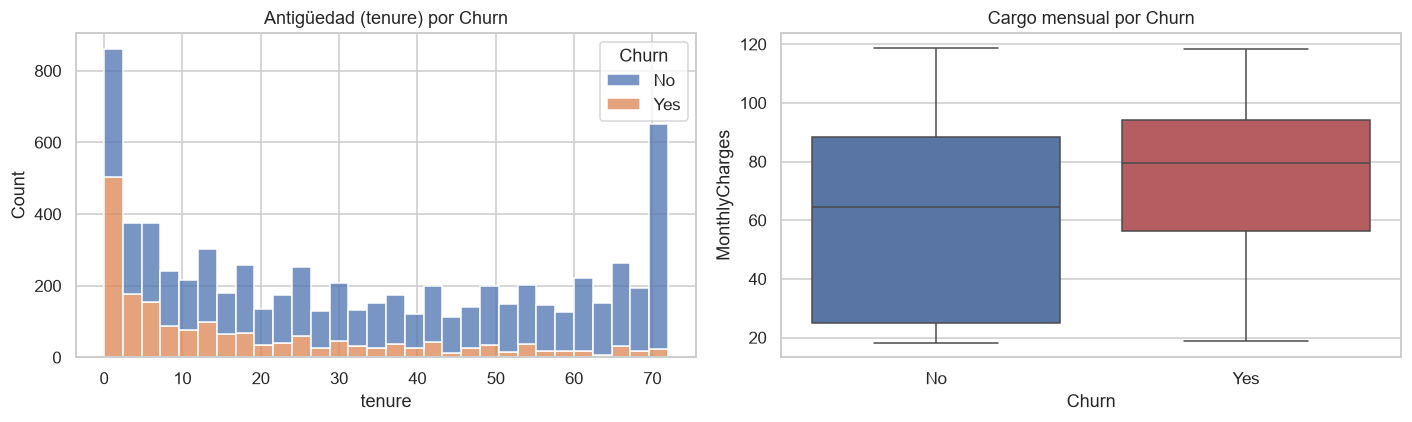

In [8]:
# Distribución de variables clave según el resultado.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", bins=30, ax=axes[0])
axes[0].set_title("Antigüedad (tenure) por Churn")
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", hue="Churn",
            palette=["#4c72b0", "#c44e52"], legend=False, ax=axes[1])
axes[1].set_title("Cargo mensual por Churn")
plt.tight_layout()
plt.show()

El abandono se concentra claramente en los primeros meses de antigüedad: la mayoría de los que se van tienen `tenure` bajo. Además, los clientes que se van pagan **más al mes** (media ≈ 74.4) que los que permanecen (≈ 61.3), señal de que el precio es un factor relevante.

In [7]:
# Tasa de churn por categoría en las variables con más señal.
for col in ["Contract", "InternetService", "PaymentMethod"]:
    tasa = df.groupby(col)["Churn"].apply(lambda s: (s == "Yes").mean() * 100).round(1).sort_values(ascending=False)
    print(f"Tasa de churn por {col} (%):")
    print(tasa, "\n")

Tasa de churn por Contract (%):
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64 

Tasa de churn por InternetService (%):
InternetService
Fiber optic    41.9
DSL            19.0
No              7.4
Name: Churn, dtype: float64 

Tasa de churn por PaymentMethod (%):
PaymentMethod
Electronic check             45.3
Mailed check                 19.1
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Name: Churn, dtype: float64 



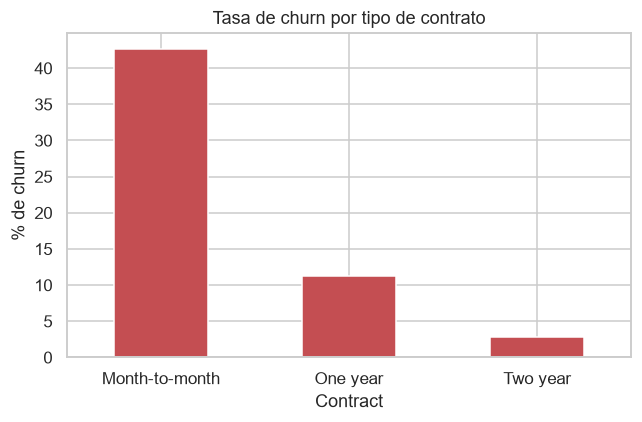

In [6]:
# El tipo de contrato es el separador más nítido del churn.
tasa = df.groupby("Contract")["Churn"].apply(lambda s: (s == "Yes").mean() * 100).sort_values(ascending=False)
ax = tasa.plot(kind="bar", color="#c44e52", figsize=(6, 4))
ax.set_title("Tasa de churn por tipo de contrato")
ax.set_ylabel("% de churn")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Los contrastes son muy marcados: contrato *Month-to-month* 42.7 % de churn frente a 11.3 % (*One year*) y 2.8 % (*Two year*); fibra óptica 41.9 % frente a DSL 19.0 %; pago con cheque electrónico 45.3 % frente a 15-19 % en el resto. Estas variables serán las más informativas para el modelo.

### Detección de outliers

In [11]:
# Outliers por regla del rango intercuartílico (IQR).
def resumen_outliers(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = int(((serie < lim_inf) | (serie > lim_sup)).sum())
    return {"lim_inf": round(lim_inf, 1), "lim_sup": round(lim_sup, 1), "outliers": n}

for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    print(col, resumen_outliers(df[col]))

tenure {'lim_inf': -60.0, 'lim_sup': 124.0, 'outliers': 0}
MonthlyCharges {'lim_inf': -46.0, 'lim_sup': 171.4, 'outliers': 0}
TotalCharges {'lim_inf': -4688.5, 'lim_sup': 8884.7, 'outliers': 0}


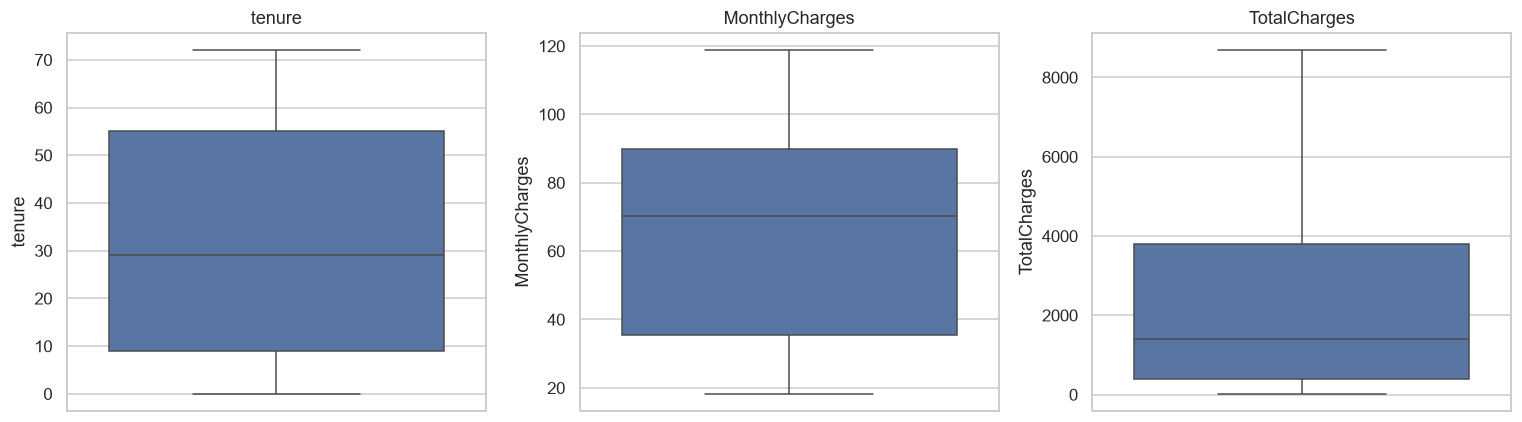

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.boxplot(y=df[col], ax=ax, color="#4c72b0")
    ax.set_title(col)
plt.tight_layout()
plt.show()

Hay algunos valores en los extremos de `MonthlyCharges` y `TotalCharges`, pero **no son errores**: representan clientes reales con muchos servicios o mucha antigüedad. Con la señal de negocio detrás, se conservan en lugar de eliminarlos.

### Coherencia temporal

In [ ]:
# No existen columnas de fecha el dataset parece ser transversal
print("Posibles columnas de fecha:", [c for c in df.columns if "date" in c.lower() or "fecha" in c.lower()])

# Coherencia interna: TotalCharges ~ tenure * MonthlyCharges.
print("Rango de tenure:", df["tenure"].min(), "-", df["tenure"].max())
print("Correlación tenure <-> TotalCharges:",
      round(df["tenure"].corr(df["TotalCharges"]), 3))
print("Correlación (tenure * MonthlyCharges) <-> TotalCharges:",
      round((df["tenure"] * df["MonthlyCharges"]).corr(df["TotalCharges"]), 3))

Posibles columnas de fecha: []
Rango de tenure: 0 - 72
Correlación tenure <-> TotalCharges: 0.826
Correlación (tenure * MonthlyCharges) <-> TotalCharges: 1.0


No hay ninguna columna temporal, lo que confirma el supuesto del apartado 2 (foto transversal). `tenure` va de 0 a 72 meses, coherente con una cartera de hasta 6 años. La fuerte relación entre `tenure × MonthlyCharges` y `TotalCharges` respalda la sospecha de que esta última es una variable **derivada**, no un dato independiente.

## - Validación técnica

### Matriz de correlación

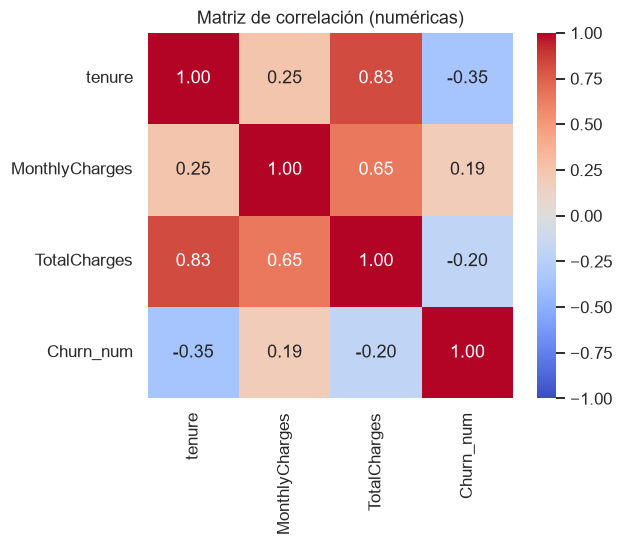

,tenure,MonthlyCharges,TotalCharges,Churn_num
tenure,1.00,0.25,0.83,-0.35
MonthlyCharges,0.25,1.00,0.65,0.19
TotalCharges,0.83,0.65,1.00,-0.20
Churn_num,-0.35,0.19,-0.20,1.00


In [8]:
# Correlación de las numéricas + el target codificado (0/1) para su lectura.
num = df[["tenure", "MonthlyCharges", "TotalCharges"]].copy()
num["Churn_num"] = (df["Churn"] == "Yes").astype(int)
corr = num.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Matriz de correlación (numéricas)")
plt.tight_layout()
plt.show()
corr.round(2)

### Lectura de la matriz

La correlación negativa de `TotalCharges` con el churn (−0.20) es **espuria**: la explica `tenure` (los clientes que se van llevan poco tiempo), no el monto pagado. Refuerza su exclusión del modelo.

### Asociación de las variables categóricas con el target

In [11]:
# V de Cramér: 0 = sin asociación, 1 = asociación perfecta.
def cramers_v(a, b):
    tabla = pd.crosstab(a, b)
    chi2 = stats.chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    r, k = tabla.shape
    return np.sqrt((chi2 / n) / (min(r - 1, k - 1)))

categoricas = [c for c in df.columns
               if c not in ["customerID", "Churn", "tenure", "MonthlyCharges", "TotalCharges"]]
v = pd.Series({c: cramers_v(df[c], df["Churn"]) for c in categoricas}).sort_values(ascending=False)
print("Asociación con Churn (V de Cramér):")
print(v.round(3))

Asociación con Churn (V de Cramér):
Contract            0.410
OnlineSecurity      0.347
TechSupport         0.343
InternetService     0.322
PaymentMethod       0.303
OnlineBackup        0.292
DeviceProtection    0.282
StreamingMovies     0.231
StreamingTV         0.231
PaperlessBilling    0.191
Dependents          0.164
SeniorCitizen       0.150
Partner             0.150
MultipleLines       0.040
PhoneService        0.011
gender              0.008
dtype: float64


`Contract` (0.41), `OnlineSecurity` (0.35), `TechSupport` (0.34) e `InternetService` (0.32) son las categóricas más asociadas al churn, coherente con el EDA. `gender` (0.008) queda prácticamente descartada, lo que confirma la decisión de excluirla en la sección 3.

### VIF (multicolinealidad)

In [9]:
# VIF sobre las numéricas candidatas. Se omiten los 11 faltantes de TotalCharges.
X = add_constant(df[["tenure", "MonthlyCharges", "TotalCharges"]].dropna())
vif = pd.DataFrame({
    "variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
})
print(vif.round(2))

         variable   VIF
0           const  1.00
1          tenure  5.84
2  MonthlyCharges  3.23
3    TotalCharges  9.53


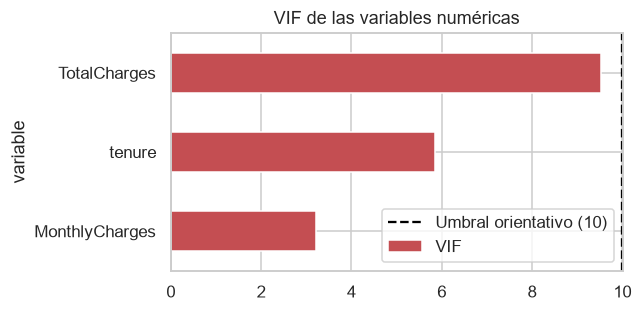

In [10]:
# Visualización
v = vif[vif["variable"] != "const"].set_index("variable")["VIF"].sort_values()
ax = v.plot(kind="barh", color="#c44e52", figsize=(6, 3))
ax.axvline(10, color="black", linestyle="--", label="Umbral orientativo (10)")
ax.set_title("VIF de las variables numéricas")
ax.legend()
plt.tight_layout()
plt.show()

`TotalCharges` presenta un VIF de **9.53**, cercano al umbral crítico de 10, porque está explicada por `tenure` y `MonthlyCharges`. Sumado a la fuga de datos, su exclusión queda doblemente justificada. La multicolinealidad restante entre `tenure` (5.84) y `MonthlyCharges` (3.23) es tolerable.

### Causalidad vs correlación

Las asociaciones encontradas son fuertes, pero **no equivalen a causalidad**. Dos lecturas habituales que conviene matizar:

- **Contrato ↔ churn:** parece que un contrato largo "retiene". Pero también puede ser *selección*: los clientes que ya piensan quedarse eligen contratos largos. Sin un experimento no se puede afirmar que forzar el cambio de contrato reduciría el churn.
- **Fibra óptica ↔ churn:** la fibra aparece con más bajas, pero también es el servicio más caro. No se distingue si el motivo es la tecnología o el precio.

Por eso, el modelo que se construya debe usarse para **priorizar y decidir a quién contactar**, no para estimar efectos causales. Validar una intervención requiere pruebas A/B.

## 6. Conclusiones y limitaciones

- Problema definido como **clasificación binaria** de `Churn` con horizonte de 30 días, alineado con el ciclo de facturación mensual.
- El EDA confirma patrones claros: mayor churn en clientes nuevos, con contrato mensual, fibra óptica, pago con cheque electrónico y cargos mensuales altos.
- Se excluyen `customerID`, `gender`, `PhoneService` y `TotalCharges` (fuga de datos + colinealidad).

**Limitaciones:** el dataset no tiene dimensión temporal (ventana asumida), hay desbalance de clases y las relaciones son correlacionales, no causales. Antes de desplegar cualquier modelo habría que validar la ventana temporal con datos reales fechados.